# **CSL2050: Pattern Recognition and Machine Learning**
## **Course Project: Hand-drawn Sketch Recognition**

### **Step 1:** Importing the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

# Define paths
zip_path = "/content/drive/My Drive/Dataset_PNG.zip"  # Space in "My Drive" is fine here
extract_path = "/content/Dataset_PNG"

# Create extract folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Verify extraction
print(os.listdir(extract_path))

Mounted at /content/drive
['sketches_png']


In [ ]:
!apt-get install unzip -y
!unzip "/content/drive/My Drive/Dataset_PNG.zip" -d /content/Dataset_PNG

Streaming output truncated to the last 5000 lines.
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15001.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15002.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15003.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15004.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15005.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15006.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15007.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15008.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15009.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15010.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15011.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15012.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15013.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15014.png

In [ ]:
dataset_path = "/content/Dataset_PNG/sketches_png/png"

# Check the extracted dataset folder
print(os.listdir(dataset_path))  # Should show category folders like 'zebra', 'cat', etc.

# Check some images inside a category
sample_category = os.path.join(dataset_path, "zebra")  # Change to any category name
print(os.listdir(sample_category)[:5])  # List first 5 images

['race car', 'binoculars', 'bench', 'ashtray', 'trumpet', 'boomerang', 'person sitting', 'crocodile', 'parking meter', 'saxophone', 'hot-dog', 'tv', 'cell phone', 'barn', 'loudspeaker', 'rooster', 'rollerblades', 'sheep', 'pipe (for smoking)', 'wineglass', 'book', 'potted plant', 'panda', 'teddy-bear', 'face', 'trombone', 'door', 'standing bird', 'horse', 'spoon', 'flying saucer', 'human-skeleton', 'snake', 'eyeglasses', 'snowman', 'cake', 'sailboat', 'chair', 'pretzel', 'sword', 'shoe', 'strawberry', 'cup', 'windmill', 'mug', 'giraffe', 'shovel', 'ear', 'wheel', 'airplane', 'cannon', 'present', 'pizza', 'scissors', 'harp', 'pen', 'armchair', 'squirrel', 'revolver', 'speed-boat', 'toilet', 'moon', 'banana', 'candle', 'lightbulb', 'house', 'teapot', 'mushroom', 'megaphone', 'violin', 'backpack', 'grenade', 'camel', 'tooth', 'ant', 'bottle opener', 'alarm clock', 'hourglass', 'comb', 'tomato', 'submarine', 'computer-mouse', 'van', 'arm', 'fire hydrant', 'monkey', 'tractor', 'syringe', 't

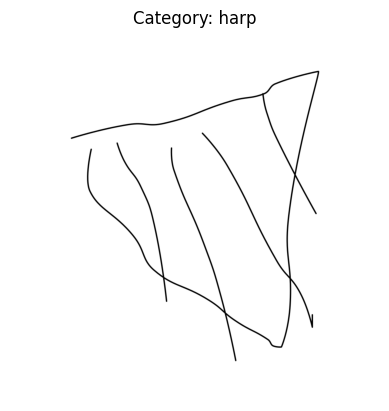

In [ ]:
import cv2
import matplotlib.pyplot as plt
import random

# Pick a random category
categories = os.listdir(dataset_path)
random_category = random.choice(categories)

# Pick a random image from the category
image_folder = os.path.join(dataset_path, random_category)
image_name = random.choice(os.listdir(image_folder))
image_path = os.path.join(image_folder, image_name)

# Load and display the image
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
plt.imshow(image, cmap='gray')
plt.title(f"Category: {random_category}")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
categories = os.listdir(dataset_path)
data = []
labels = []
for category in categories:
    category_path = os.path.join(dataset_path, category)
    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Load in grayscale
        img = cv2.resize(img, (64, 64))  # Resize to 64x64
        data.append(img.flatten())  # Flatten the image to a 1D array
        labels.append(category)

# Convert to NumPy arrays
data = np.array(data)
labels = np.array(labels)

# Encode labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

# Split data
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from skimage.feature import hog

# Reshape 'data' correctly to match the original image dimensions
# Assuming your original images were 64x64, you should reshape like this:
data_reshaped = data.reshape(-1, 64, 64)

# Compute HOG features
data_hog = []
for img in data_reshaped:  # Iterate over the reshaped data
    hog_features = hog(img, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
    data_hog.append(hog_features)
data_hog = np.array(data_hog)
print(f"HOG feature size: {data_hog.shape}")

# Split and scale (now with consistent shapes)
X_train_hog, X_test_hog, y_train, y_test = train_test_split(data_hog, labels, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_hog_scaled = scaler.fit_transform(X_train_hog)
X_test_hog_scaled = scaler.transform(X_test_hog)

# Train KNN with distance weighting
knn = KNeighborsClassifier(n_neighbors=10, weights='distance')
knn.fit(X_train_hog_scaled, y_train)
y_pred = knn.predict(X_test_hog_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy with HOG and distance weighting (k=10): {accuracy:.2f}")
print(f"Predicted labels (sample): {y_pred[:10]}")
print(f"True labels (sample): {y_test[:10]}")

HOG feature size: (20000, 1764)
KNN Accuracy with HOG and distance weighting (k=10): 0.06
Predicted labels (sample): [ 89  73 107 188 144 196 204 188 216  44]
True labels (sample): [193 218 109 160 203 132  71 188 247  32]


knn vs k graph


  0%|          | 0/250 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
100%|██████████| 250/250 [03:49<00:00,  1.09it/s]


Finding optimal k value...


100%|██████████| 15/15 [21:55<00:00, 87.72s/it]


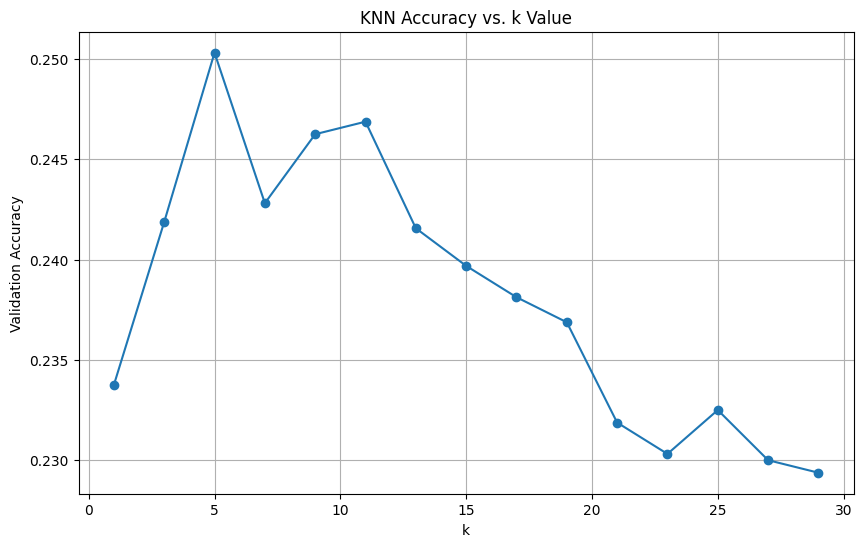

Optimal k value: 5
Improved Test Accuracy: 0.2712

Balanced Accuracy Report:
                    precision    recall  f1-score   support

          airplane       0.20      0.12      0.15        16
       alarm clock       0.40      0.38      0.39        16
             angel       0.50      0.06      0.11        16
               ant       0.14      0.12      0.13        16
             apple       0.40      0.38      0.39        16
               arm       0.06      0.06      0.06        16
          armchair       0.00      0.00      0.00        16
           ashtray       0.00      0.00      0.00        16
               axe       0.38      0.56      0.45        16
          backpack       0.33      0.12      0.18        16
            banana       0.23      0.38      0.29        16
              barn       0.43      0.19      0.26        16
      baseball bat       0.37      0.44      0.40        16
            basket       0.06      0.12      0.08        16
           bathtub    

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from skimage.feature import hog, local_binary_pattern
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Enhanced feature extraction
def extract_features(img):
    # HOG features
    hog_feat = hog(img, orientations=9, pixels_per_cell=(16, 16),
                   cells_per_block=(2, 2), block_norm='L2-Hys')

    # LBP features (complements HOG well for sketches)
    lbp = local_binary_pattern(img, P=8, R=1, method='uniform')
    lbp_hist = np.histogram(lbp, bins=10, range=(0, 10))[0]

    # Simple shape features
    img_uint8 = (img * 255).astype(np.uint8)
    edges = cv2.Canny(img_uint8, 100, 200)
    edge_density = np.mean(edges) / 255

    return np.concatenate([hog_feat, lbp_hist, [edge_density]])

# Load data with enhanced features
def load_enhanced_features(dataset_path, max_samples=100):
    categories = os.listdir(dataset_path)
    X, y = [], []

    for category in tqdm(categories):
        cat_path = os.path.join(dataset_path, category)
        samples = 0

        for img_name in os.listdir(cat_path)[:max_samples]:
            img_path = os.path.join(cat_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, (128, 128))
            img = img / 255.0  # Normalize
            features = extract_features(img)
            X.append(features)
            y.append(category)
            samples += 1

            if samples >= max_samples:
                break

    return np.array(X), np.array(y)

# Load data
dataset_path = "/content/Dataset_PNG/sketches_png/png"
X, y = load_enhanced_features(dataset_path, max_samples=100)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to find best k and plot KNN vs k graph
def find_best_k(X_train, y_train, X_val, y_val, max_k=30):
    best_k = 1
    best_score = 0
    scores = []

    print("Finding optimal k value...")
    for k in tqdm(range(1, max_k + 1, 2)):  # Step by 2 for odd k values
        knn = KNeighborsClassifier(
            n_neighbors=k,
            weights='distance',
            metric='manhattan',
            algorithm='ball_tree',
            n_jobs=-1
        )
        knn.fit(X_train, y_train)
        score = knn.score(X_val, y_val)
        scores.append(score)
        if score > best_score:
            best_score = score
            best_k = k

    # Plot KNN vs k graph
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, max_k + 1, 2), scores, marker='o')
    plt.title('KNN Accuracy vs. k Value')
    plt.xlabel('k')
    plt.ylabel('Validation Accuracy')
    plt.grid(True)
    plt.show()

    return best_k

# Create validation set for k tuning
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42)

# Find best k and plot graph
best_k = find_best_k(X_train_sub, y_train_sub, X_val, y_val)
print(f"Optimal k value: {best_k}")

# Train final KNN model with best k
best_knn = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance',
    metric='manhattan',
    algorithm='ball_tree',
    n_jobs=-1
)

best_knn.fit(X_train_scaled, y_train)

# Evaluation
y_pred = best_knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Improved Test Accuracy: {accuracy:.4f}")

# Classification report
print("\nBalanced Accuracy Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

knn using hog features


pca vs hog

Starting optimized random search with reduced PCA components...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best params: {'knn__leaf_size': 40, 'knn__n_neighbors': 12, 'pca__n_components': 70}
Test Accuracy with PCA: 0.2988
Original Accuracy (no PCA): 0.2747


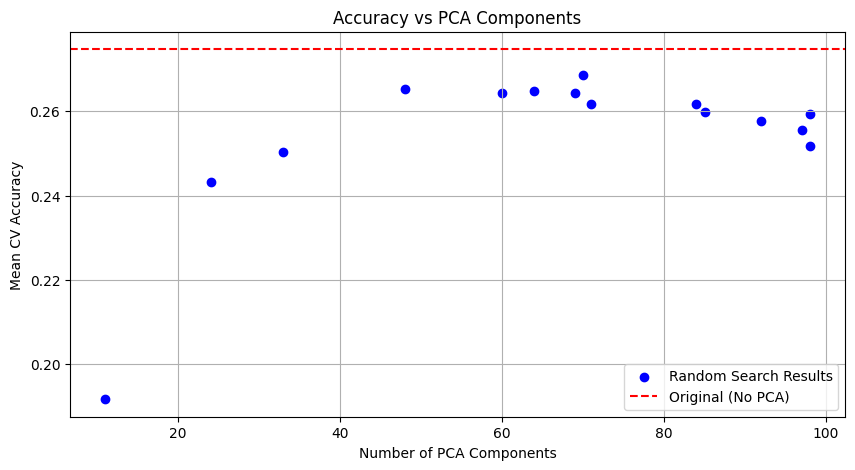

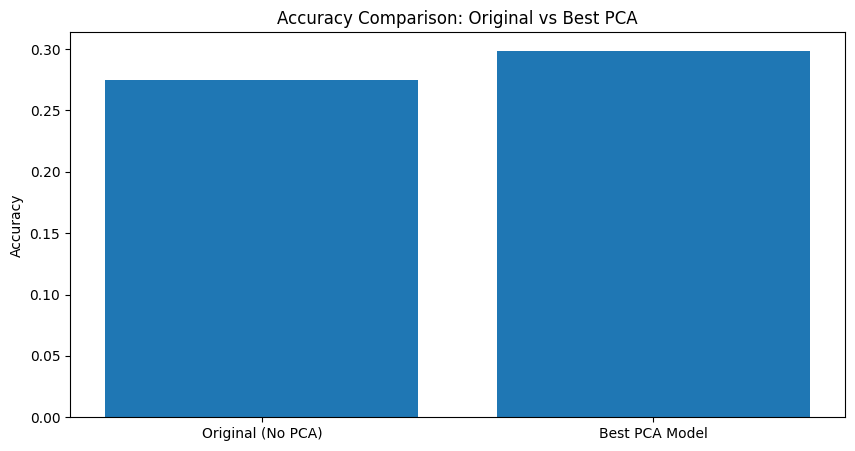

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from scipy.stats import randint
import matplotlib.pyplot as plt
from tempfile import mkdtemp
from shutil import rmtree

# Assuming X_train, X_test, y_train, y_test, X_test_scaled, best_knn are defined
# If not, replace with your data from earlier code

# Define parameter distribution with reduced PCA components
param_dist = {
    'pca__n_components': randint(10, 100),  # Reduced range: 10 to 100 components
    'knn__n_neighbors': randint(5, 25),
    'knn__leaf_size': [20, 30, 40]
}

# Create temporary directory for caching
cachedir = mkdtemp()

# Pipeline with caching
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA()),
    ('knn', KNeighborsClassifier(weights='distance', metric='manhattan'))
], memory=cachedir)

# Randomized search with fewer iterations
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting optimized random search with reduced PCA components...")
random_search.fit(X_train, y_train)

# Clean up cache
rmtree(cachedir)

# Evaluate best model
best_model = random_search.best_estimator_
print(f"\nBest params: {random_search.best_params_}")
y_pred = best_model.predict(X_test)
best_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy with PCA: {best_accuracy:.4f}")

# Compare with original KNN (no PCA)
original_accuracy = accuracy_score(y_test, best_knn.predict(X_test_scaled))
print(f"Original Accuracy (no PCA): {original_accuracy:.4f}")

# Visualize accuracy vs PCA components
results = random_search.cv_results_
n_components = results['param_pca__n_components']
accuracies = results['mean_test_score']

plt.figure(figsize=(10, 5))
plt.scatter(n_components, accuracies, c='blue', label='Random Search Results')
plt.axhline(y=original_accuracy, color='r', linestyle='--', label='Original (No PCA)')
plt.xlabel('Number of PCA Components')
plt.ylabel('Mean CV Accuracy')
plt.title('Accuracy vs PCA Components')
plt.legend()
plt.grid(True)
plt.show()

# Bar comparison
plt.figure(figsize=(10, 5))
plt.bar(['Original (No PCA)', 'Best PCA Model'], [original_accuracy, best_accuracy])
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison: Original vs Best PCA')
plt.show()